Multivariate EDA isn’t description — it’s selection. Every plot in notebook 3 should end in a verdict: keep this feature, drop it, transform it, or “this pattern is a confound.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(
  style='darkgrid',
)

In [4]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

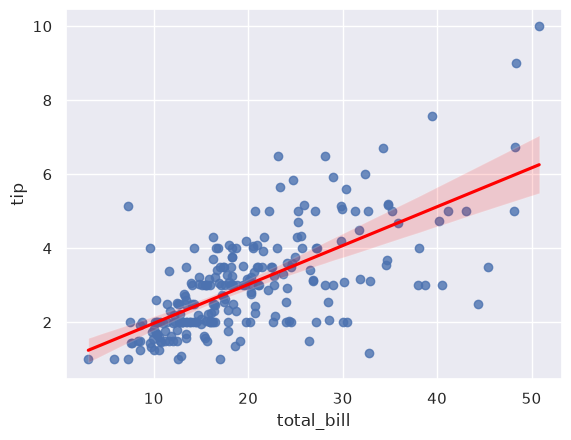

In [5]:
sns.regplot(data=df, x='total_bill', y='tip', line_kws={'color': 'red'})

#INFO: The regression line shows a positive correlation between total bill and tip, and also it shows that their relationship is linear.
#INFO: The spread is not constant. The variance of tip clearly increases as total_bill grows.

# Question:
Which gender pays more overall ?

<Axes: xlabel='total_bill', ylabel='tip'>

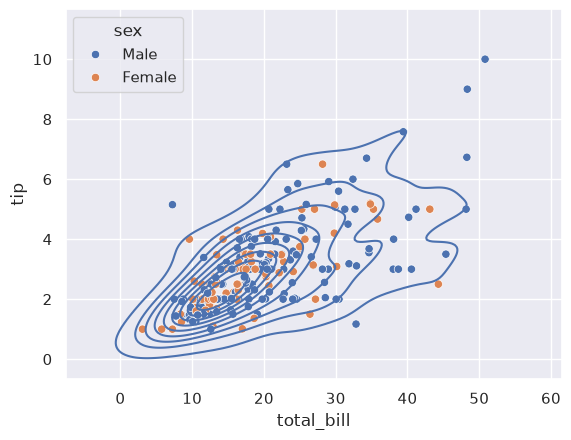

In [13]:
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
sns.kdeplot(data=df, x='total_bill', y='tip')

#INFO: As distance from the median increases, the male-to-female ratio widens significantly, with males dominating the high-end outliers.

# Question:
Men pay more, but are Men actually more generouse than Women in giving tips?

<Axes: xlabel='sex', ylabel='tip_percentage'>

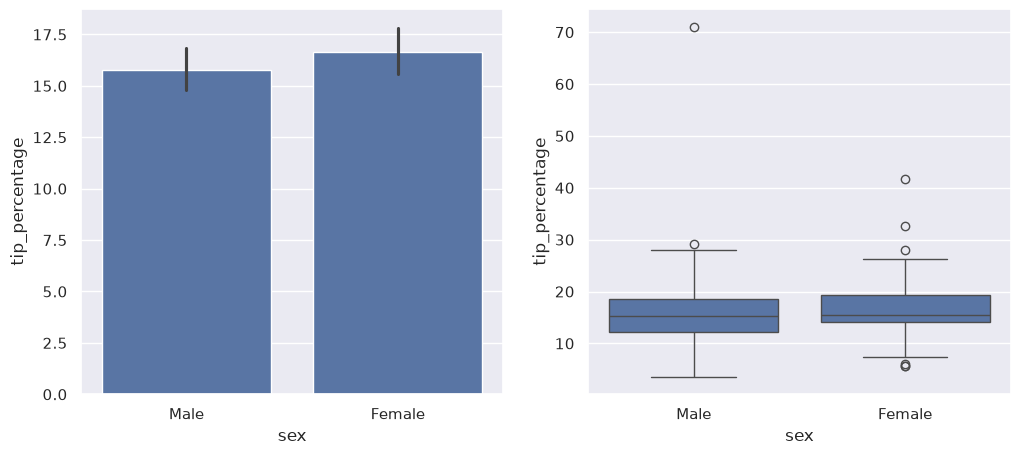

In [ ]:
df['tip_percentage'] = df['tip'] / df['total_bill'] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, y='tip_percentage', x='sex', ax=ax1)
sns.boxplot(data=df, x='sex', y='tip_percentage', ax=ax2)

#INFO: The bar plot shows that the average tip percentage is higher for females than males, indicating that females tend to tip more generously than males on average.

#INFO: The difference between male & female tip percentages is not very large. and this difference mostly is because of noise. 
#      Which means the "sex" feature is not a good predictor of tip percentage.

# Question:
Is "smoker" a good predictor for tip amount?

<Axes: xlabel='smoker', ylabel='tip_percentage'>

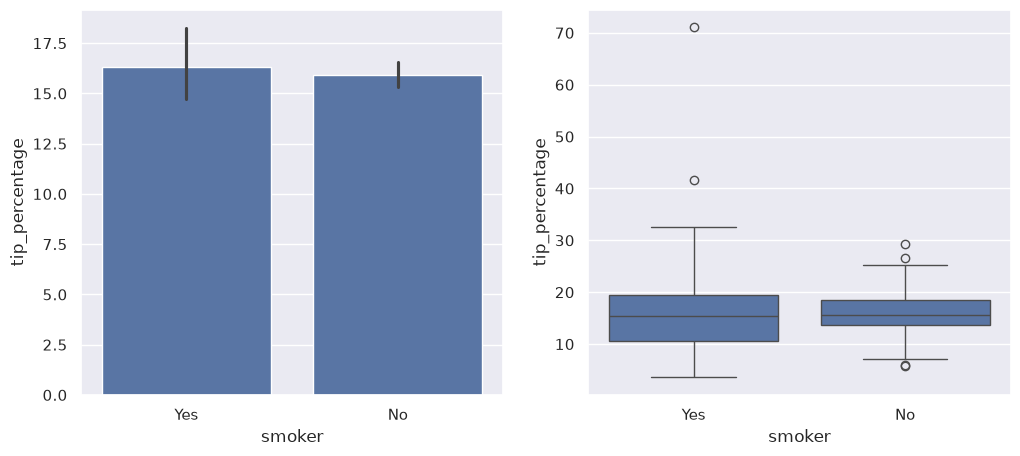

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, y='tip_percentage', x='smoker', ax=ax1)
sns.boxplot(data=df, x='smoker', y='tip_percentage', ax=ax2)

#INFO: Smokers and non-smokers have similar average tip percentages. which indicates that smoking status does not significantly affect tipping behavior in this dataset.
#      But, error bar in smokers is larger than non-smokers, which indicates that smokers have more variability in their tipping behavior compared to non-smokers.

# Question:
What effect day of week and time of day have on total bill and tip?

<Axes: xlabel='time', ylabel='tip'>

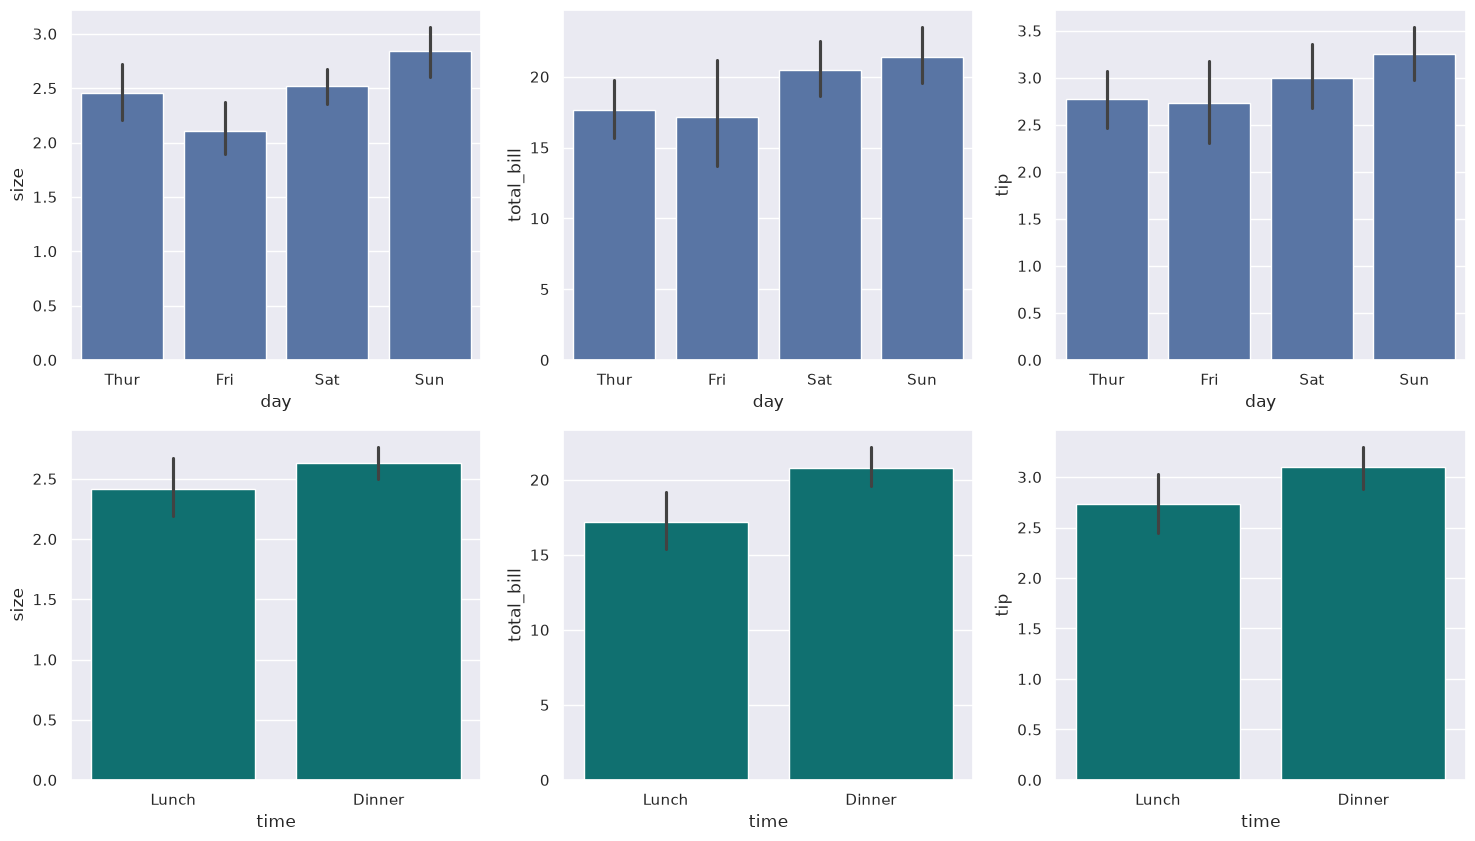

In [9]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(18, 10))

sns.barplot(data=df, x='day', y='size', ax=ax1)
sns.barplot(data=df, x='day', y='total_bill', ax=ax2)
sns.barplot(data=df, x='day', y='tip', ax=ax3)

sns.barplot(data=df, x='time', y='size', ax=ax4, color='teal')
sns.barplot(data=df, x='time', y='total_bill', ax=ax5, color='teal')
sns.barplot(data=df, x='time', y='tip', ax=ax6, color='teal')

#INFO: day of the week and time of day have effect on the table size and also total bill, and then it effects the tip amount.

# Question

Does day of week, or time of day, directly effect the amount of tip, regardless of bill amount?

<Axes: xlabel='day', ylabel='total_bill'>

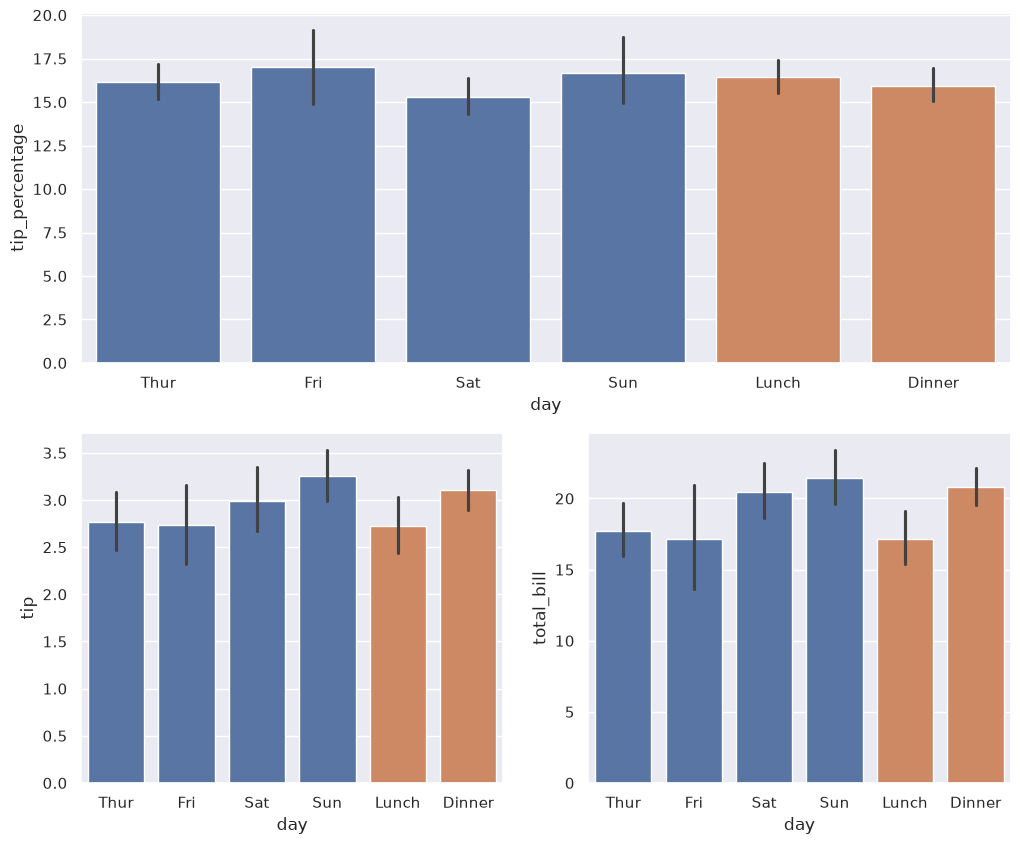

In [10]:
# fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

#The overlap here is intentional. the time of day only has two values, so it's easier and more comfortable to show both day of week and time of day in the same plot.
sns.barplot(data=df, y='tip_percentage', x='day', ax=ax1)
sns.barplot(data=df, y='tip_percentage', x='time', ax=ax1)

sns.barplot(data=df, y='tip', x='day', ax=ax2)
sns.barplot(data=df, y='tip', x='time', ax=ax2)

sns.barplot(data=df, y='total_bill', x='day', ax=ax3)
sns.barplot(data=df, y='total_bill', x='time', ax=ax3)


#INFO: bar plots show that the average tip percentage doesn't change significantly across different days of the week or between lunch and dinner times.
#      and the little difference in tip percentage across days and times is likely due to noise rather than a meaningful pattern.
#INFO: What day of week or time of day effects is the total bill, and then total bill affects the tip amount.
#      Which means using the day of week or time of day as a predictor for tip amount is not very effective, and it's better to use total bill as a predictor instead.

# Question:

Does size of the table, directly effect the tip amount, or it just effects the total bill?

<Axes: xlabel='size', ylabel='tip'>

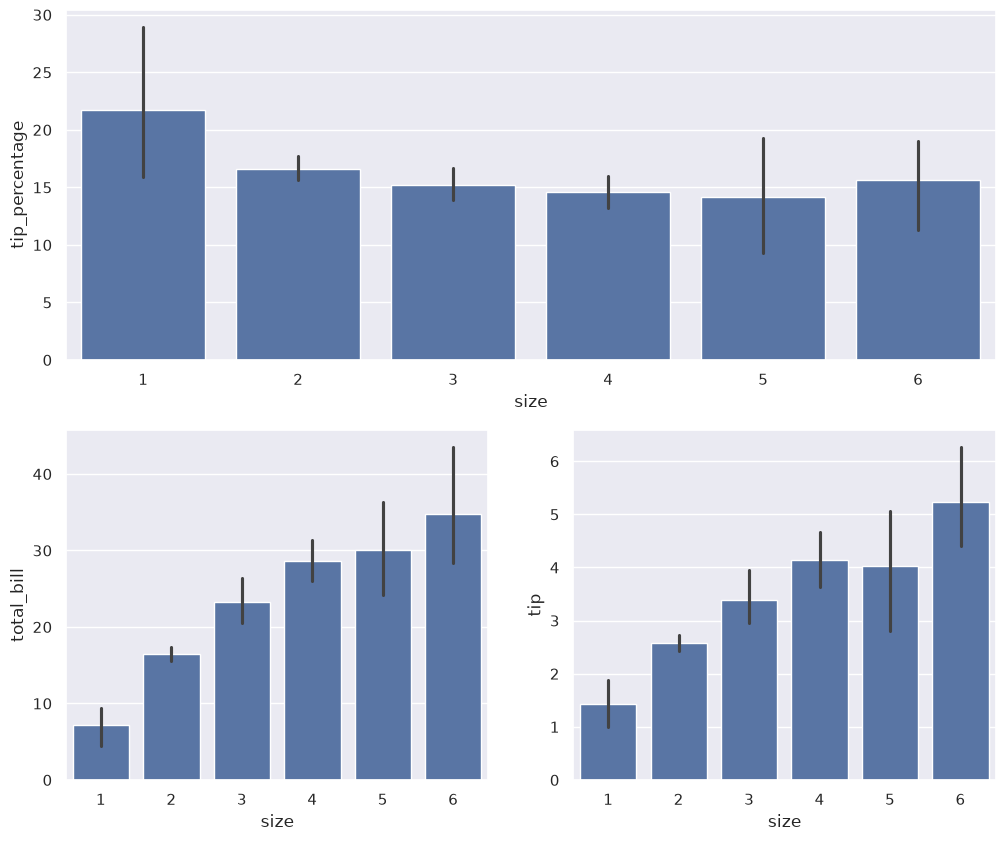

In [11]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

sns.barplot(data=df, y='tip_percentage', x='size', ax=ax1)
sns.barplot(data=df, y='total_bill', x='size', ax=ax2)
sns.barplot(data=df, y='tip', x='size', ax=ax3)


#INFO: Bar plots show that the size of the talbe, have a predictable effect on the total bill and tip amount.
#INFO: size 2+ shows a mild negative trend; the size-1 effect is n=4 and unusable.

<Axes: >

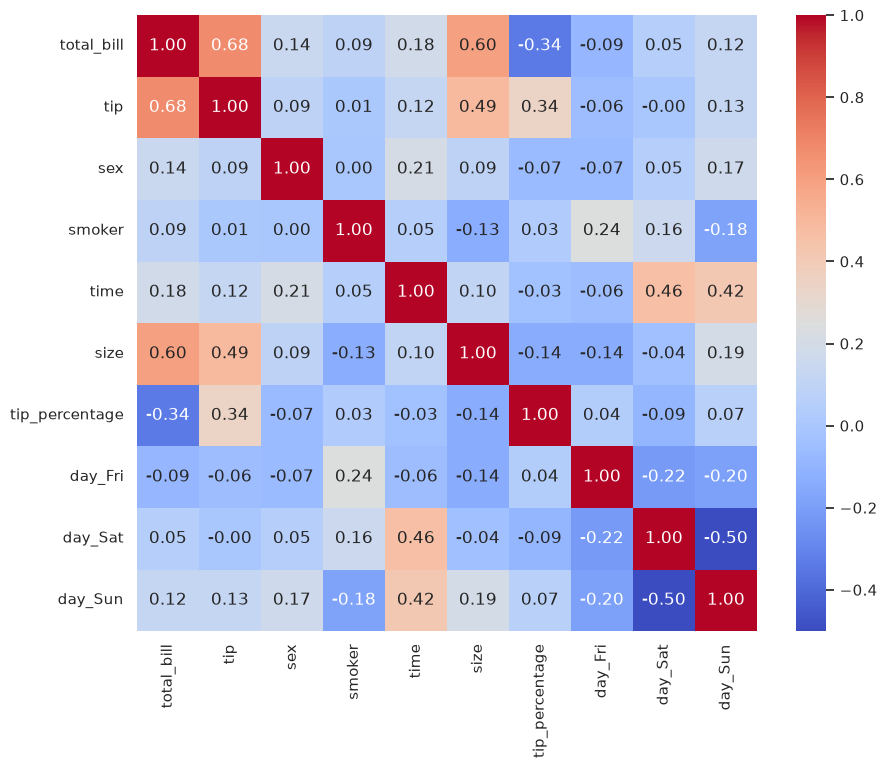

In [12]:
df_modified = df.copy()
df_modified['sex'] = df_modified['sex'].map({'Male': 1, 'Female': 0})
df_modified['smoker'] = df_modified['smoker'].map({'Yes': 1, 'No': 0})
df_modified['time'] = df_modified['time'].map({'Dinner': 1, 'Lunch': 0})
df_modified = pd.get_dummies(df_modified, columns=['day'], drop_first=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df_modified.corr(), cmap='coolwarm', annot=True, fmt='.2f', )